In [12]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [13]:
# --- User toggle ---
Cristina = False
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Shar's Dirac server setup


In [36]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "local_MDwarfFlares_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




[INFO] Loaded metric module: local_MDwarfFlares_metric
[INFO] Loaded shared_utils module


In [50]:
76*10**9/((4/3)*np.pi*(.03**3-0.0000013**3))

671987537499168.5

In [17]:
#metric configurations
use_kcorrect=False
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = True 
generate_new_pop = True
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 76*10**9/((4/3)*np.pi*(.03**3-0.0000013**3)) /1000000
#dividing by 1000000 so that we can actually use these numbers

#the milky way contains 100–400 billion stars
#76% of main sequence stars are m dwarfs
#i dont know how many non-main-sequence stars there are so...
#let's say there are 100 billion main sequence stars
#so 76 billion m dwarfs
#rate density calculation: 76*10*9 /((4/3)*np.pi*(.03**3-0.0000013**3))
#....that's the number of m dwarfs. it's supposed to be per year but it's not right now
#how many flares does a star have per year?

# apply None for non-use case 
z_min, z_max = None, None #.00226, .3
d_min, d_max = 0.0000013, .03 # #proxima cen is an m-dwarf apparently at 1.3 pc
#the milky way is 30 kpc across and the sun is 8kpc from the center
#let's just use 30 kpc because we don't have a way to weight it right now


#other
gal_lat_cut = 30 #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
# cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
cadences = ['four_roll_v5.0.0_10yrs']#, 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']

ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="MDwarfFlares", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_Mpc_ext_True_kcor_None_None


In [41]:
importlib.reload(metric)

<module 'local_MDwarfFlares_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/MDwarfFlare/local_MDwarfFlares_metric.py'>

In [42]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
initial light curve filter (g): 
{'ph': array([0.        , 0.09869305]), 'mag': array([17.75915844, 19.07579376]), 'fade_time_days': 0.09869304596298886}
flux g  q  2.3425156234609114e-08
flux g peak  7.876560692784769e-08
lc in  u :  {'ph': array([0.        , 0.09869305]), 'mag': array([18.57465262, 19.89128794])}
lc in  g :  {'ph': array([0.        , 0.09869305]), 'mag': array([17.75915844, 19.07579376])}
lc in  r :  {'ph': array([0.        , 0.09869305]), 'mag': array([18.66140594, 19.97804126])}
lc in  i :  {'ph': array([0.        , 0.09869305]), 'mag': array([19.48510516, 20.80174048])}
lc in  z :  {'ph': array([0.        , 0.09869305]), 'mag': array([20.2873693 , 21.60400462])}
lc in  y :  {'ph': array([0.        , 0.09869305]), 'mag': array([21.40540278, 22.7220381 ])}
initial light curve filter (g): 
{'ph': array([0.        , 0.08899544]), 'mag': array([19.14433501, 19.42686705]), 'fade_time_days': 0.08899544256839631}
flux g  q  1.

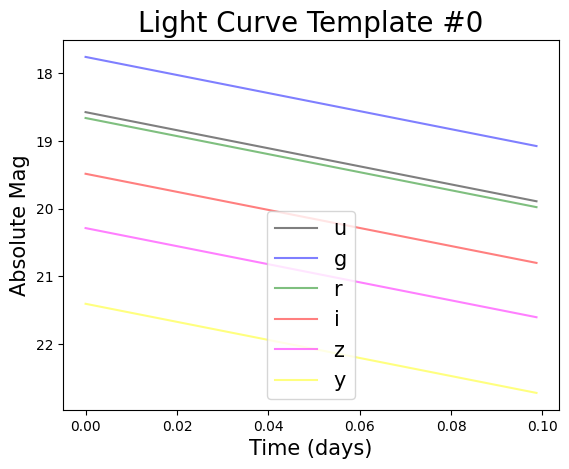

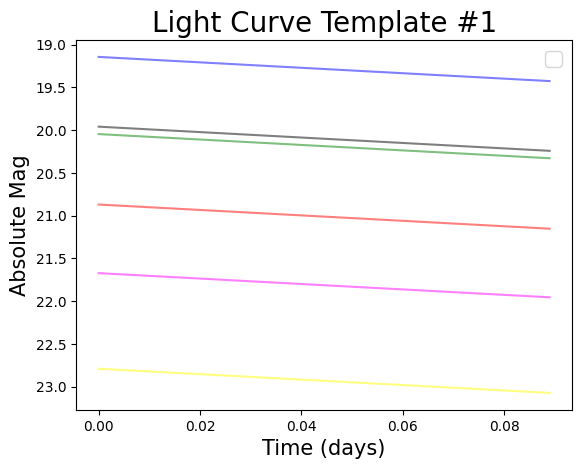

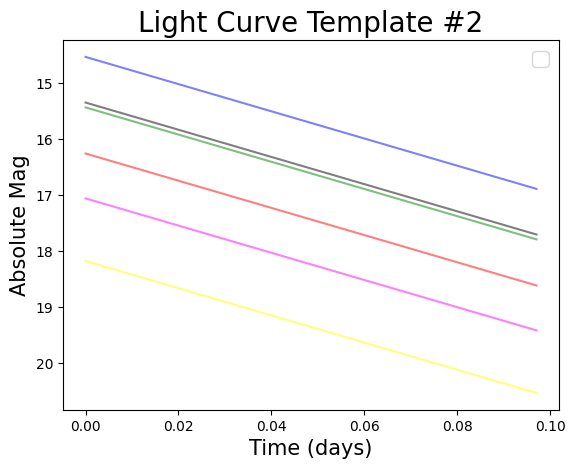

In [43]:
#plot light curves from pkl file if desired
ylim = None
use_log_time = False
plot_overlap = False
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3, use_log_time = use_log_time,plot_overlap=plot_overlap,ylim=ylim)

In [55]:
importlib.reload(shared_utils)

<module 'shared_utils' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py'>

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_Mpc_ext_True_kcor_None_None_population.pkl
Simulated 761218 events using rate_density = 6.7e+08
Len ra before masking:  761218
b:  [ 31.42221553 -69.77132472 -42.30667511 ...  17.19189448 -45.48153651
 -80.4526798 ]
len mask, num true in mask:  761218 380497
len ra after masking:  380497


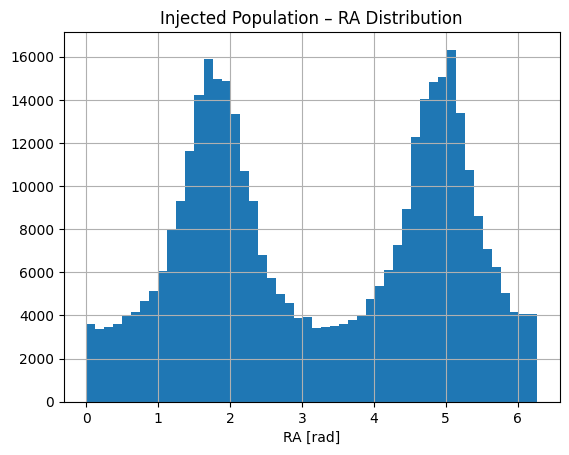

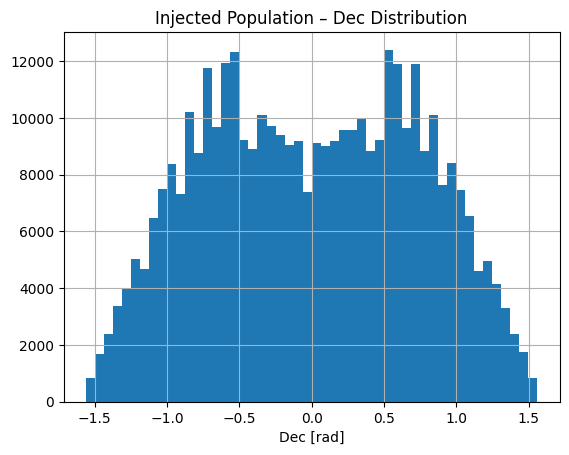

initial peak times:  [ 728.71485824 2706.24542986  131.19077693 ... 1065.67546432 2340.36232356
 1230.51624453]
[WARNING] lc_model not provided - skipping injected peak magnitude storage.
gal_lat_cut is none


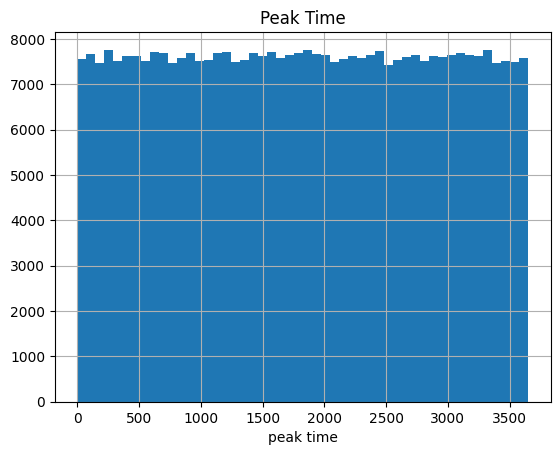

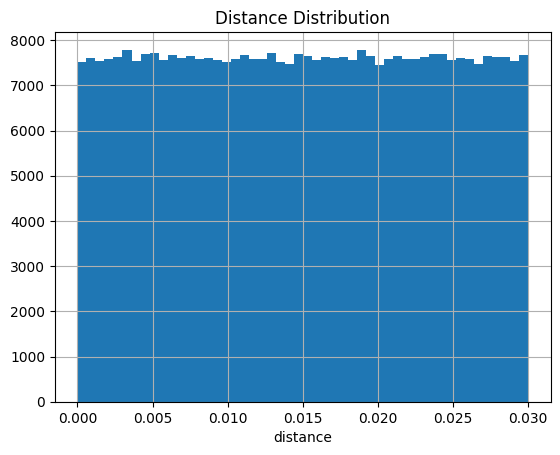

[DEBUG] coords.dec[:5]: [  7.18075578 -45.78396716 -23.31795707  36.42357364 -27.95318688] deg
[DEBUG] coords.dec.unit: deg


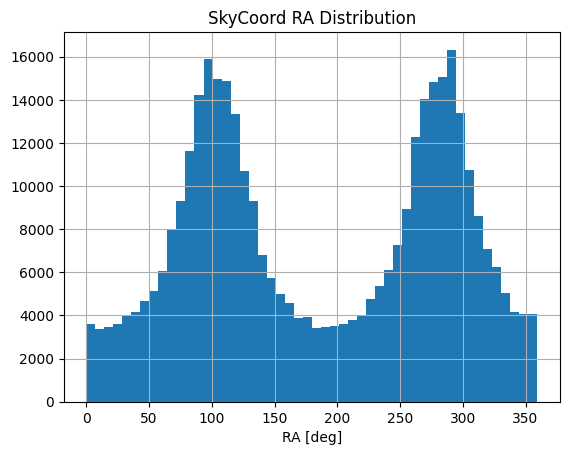

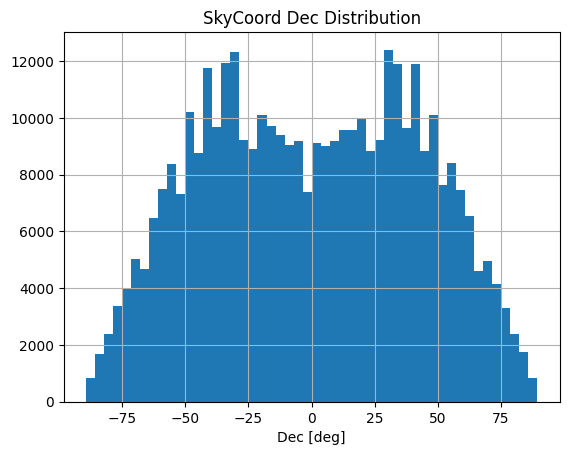

[INFO] Saved atomically to /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_Mpc_ext_True_kcor_None_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (380497,)


In [44]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


## All 10 years

In [45]:
#run detection metric
df_obs = shared_utils.run_detect(metric, slicer, cadences,  shared_lc_model, db_dir, storage_dir, df_file, use_kcorrect=False,ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---
initial light curve filter (g): 
{'ph': array([0.        , 0.09869305]), 'mag': array([17.75915844, 19.07579376]), 'fade_time_days': 0.09869304596298886}
flux g  q  2.3425156234609114e-08
flux g peak  7.876560692784769e-08
lc in  u :  {'ph': array([0.        , 0.09869305]), 'mag': array([18.57465262, 19.89128794])}
lc in  g :  {'ph': array([0.        , 0.09869305]), 'mag': array([17.75915844, 19.07579376])}
lc in  r :  {'ph': array([0.        , 0.09869305]), 'mag': array([18.66140594, 19.97804126])}
lc in  i :  {'ph': array([0.        , 0.09869305]), 'mag': array([19.48510516, 20.80174048])}
lc in  z :  {'ph': array([0.        , 0.09869305]), 'mag': array([20.2873693 , 21.60400462])}
lc in  y :  {'ph': array([0.        , 0.09869305]), 'mag': array([21.40540278, 22.7220381 ])}
initial light curve filter (g): 
{'ph': array([0.        , 0.08899544]), 'mag': array([19.14433501, 19.42686705]), 'fade_time_days': 0.08899544256839631}
flux g  q  1.695325

ValueError: Cannot set a DataFrame with multiple columns to the single column eval_peak_mag

In [61]:
importlib.reload(metric)

<module 'local_MDwarfFlares_metric' from '/home/3155/metrics/Multi_Transient_Metrics_Hub/MDwarfFlare/local_MDwarfFlares_metric.py'>

In [62]:
#choose what to run in run_multi_metrics
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['silver','gold'], use_extinction=use_extinction)


initial light curve filter (g): 
{'ph': array([0.        , 0.09869305]), 'mag': array([17.75915844, 19.07579376]), 'fade_time_days': 0.09869304596298886}
flux g  q  2.3425156234609114e-08
flux g peak  7.876560692784769e-08
lc in  u :  {'ph': array([0.        , 0.09869305]), 'mag': array([18.57465262, 19.89128794])}
lc in  g :  {'ph': array([0.        , 0.09869305]), 'mag': array([17.75915844, 19.07579376])}
lc in  r :  {'ph': array([0.        , 0.09869305]), 'mag': array([18.66140594, 19.97804126])}
lc in  i :  {'ph': array([0.        , 0.09869305]), 'mag': array([19.48510516, 20.80174048])}
lc in  z :  {'ph': array([0.        , 0.09869305]), 'mag': array([20.2873693 , 21.60400462])}
lc in  y :  {'ph': array([0.        , 0.09869305]), 'mag': array([21.40540278, 22.7220381 ])}
initial light curve filter (g): 
{'ph': array([0.        , 0.08899544]), 'mag': array([19.14433501, 19.42686705]), 'fade_time_days': 0.08899544256839631}
flux g  q  1.6953258263039917e-08
flux g peak  2.1992064243

In [ ]:
summary_df_2 = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v5.0.0_10yrs ---
(2,)
[<local_MDwarfFlares_metric.MDwarfFlareSilverMetric object at 0x2ae8eff79890>, <local_MDwarfFlares_metric.MDwarfFlareGoldMetric object at 0x2ae8dd73a710>]



--- Running four_roll_v5.0.0_10yrs ---
(1,)
EBV included
                                       Sum                     run  \
four_roll_v5.0.0_10yrs_Detect_Metric  44.0  four_roll_v5.0.0_10yrs   

                                      n_events_full_sky  
four_roll_v5.0.0_10yrs_Detect_Metric             379446  


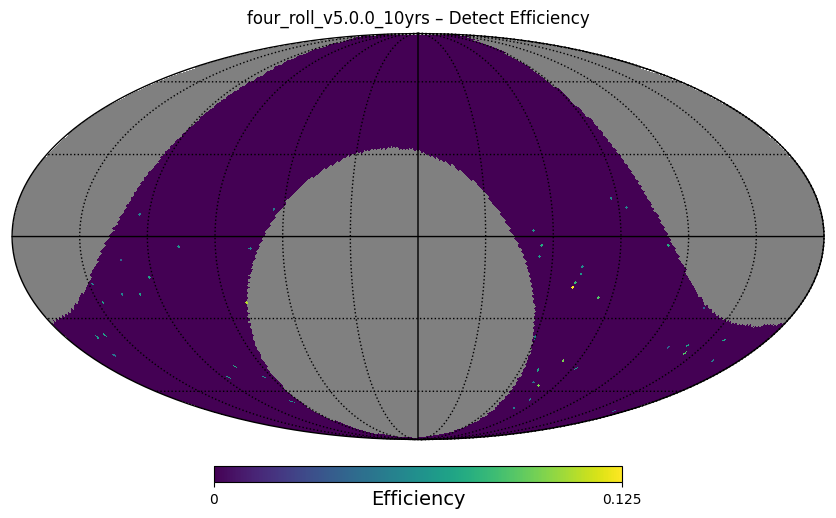

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/MDwarfFlares/Metric_temp_four_roll_v5.0.0_10yrs
saved summary to  /lustre/lrspec/metrics/results/MDwarfFlares/MDwarfFlares_den_671987537.4991685_d_1.3e-06-0.03_Mpc_z_None-None_Mpc_ext_True_kcor_None_None_None_multi_summary.csv


In [11]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [12]:
summary_df

,Sum,run,n_events_full_sky
four_roll_v5.0.0_10yrs_Detect_Metric,44.0,four_roll_v5.0.0_10yrs,379446


In [321]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected GRB Afterglows")
plt.title("Distribution of Apparent Peak Magnitudes (Detected GRB Afterglows)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'detected_df' is not defined